# Прогноз швидкості адопції тварин за фото та описом
**Олександр Коновалюк · фінальний проєкт**

Мета — передбачити клас швидкості адопції 1–4. Основна метрика — quadratic weighted
kappa (QWK); accuracy допоміжна. Порівнюємо текст, фотографії, їх поєднання,
різні фотоенкодери та ансамблі. Історичний дослідницький ноутбук і журнал зберігаються окремо.


**Навчання для сабміту:** після CV кожна модель заново навчається на **всіх рядках
`train.csv`**, включно з колишніми validation-фолдами. TF-IDF, SVD та scaler також
перенавчаються на всьому train. `test.csv` змагання не має міток і використовується
лише для прогнозу. Це реалізація вимоги об’єднати локальні навчальну й перевірочну
частини перед фінальним навчанням. Пороги визначаємо за OOF, а не за прихованими мітками.


## 1. Середовище та зафіксований протокол
П’ять стратифікованих фолдів seed 42. Дві фіксовані епохи MLP, без вибору
епох за зовнішньою валідацією. Калібрування A↔B всередині кожного held-out фолда:
пороги вчимо на одній половині, оцінюємо на іншій. Параметри та ваги ансамблів
визначено до запуску. Додаткове розбиття seed 2027 оцінює стійкість двох кандидатів.
Ці дані вже використовувалися під час розробки; це не незалежний фінальний тест.

In [1]:
%pip install -q catboost==1.2.10 transformers==5.0.0 sentence-transformers==5.4.1 nltk joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import hashlib, json, os, random, re, shutil, platform
from pathlib import Path
from types import SimpleNamespace
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image
from transformers import AutoModel, AutoImageProcessor
from sentence_transformers import SentenceTransformer
from catboost import CatBoostRegressor
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix
from scipy.optimize import differential_evolution
from tqdm.auto import tqdm
from IPython.display import display, FileLink
import joblib

DATA_ROOT = Path('/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10')
OUT = Path('/kaggle/working/adoption_clean')
CACHE_INPUT = None  # Необов’язково: папка feature_cache з попереднього ЧИСТОВОГО прогону.
RUN_SENSITIVITY = True
RUN_SENTENCE = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CFG = dict(seed=42, folds=5, epochs=2, hidden=128, dropout=.3, lr=.001,
           weight_decay=.0001, batch=64, svd_dim=128, max_features=20000, min_df=2,
           split_seed=42, optimizer_seed=42, maxiter=120, popsize=12, tol=1e-7,
           bounds=[1.,4.], minimum_gap=1e-4, training_seeds=[42,123,2026])
DINO_NAME='facebook/dinov2-small'
DINO_REV='ed25f3a31f01632728cabb09d1542f84ab7b0056'
TEXT_NAME='sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
TEXT_REV='4328cf26390c98c5e3c738b4460a05b95f4911f5'
for folder in ['feature_cache','cv42','cv2027','full_train','submissions']:
    (OUT/folder).mkdir(parents=True,exist_ok=True)

def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark=False
    torch.backends.cudnn.deterministic=True

def write_json(path,value):
    Path(path).write_text(json.dumps(value,ensure_ascii=False,indent=2),encoding='utf8')

VERSIONS={name:importlib.metadata.version(name) for name in
          ['numpy','pandas','scikit-learn','scipy','torch','torchvision','transformers',
           'sentence-transformers','catboost','nltk','joblib']}
print('Пристрій:',DEVICE)
display(pd.Series(VERSIONS,name='version'))

Пристрій: cuda


numpy                           2.0.2
pandas                          2.3.3
scikit-learn                    1.6.1
scipy                          1.16.3
torch                    2.10.0+cu128
torchvision              0.25.0+cu128
transformers                    5.0.0
sentence-transformers           5.4.1
catboost                       1.2.10
nltk                            3.9.1
joblib                          1.5.3
Name: version, dtype: object

## 2. Дані й очищення тексту
Зберігаємо перевірене очищення: розкриваємо скорочення, прибираємо URL, пунктуацію
та цифри, зберігаємо заперечення. Всі навчальні текстові перетворення надалі
підбираються лише на навчальній частині відповідного фолда.

In [3]:
def prepare_data():
    train = pd.read_csv(DATA_ROOT / 'train.csv', dtype={'PetID': str})
    test = pd.read_csv(DATA_ROOT / 'test.csv', dtype={'PetID': str})
    assert {'PetID', 'Description', 'AdoptionSpeed'} <= set(train.columns)
    assert {'PetID', 'Description'} <= set(test.columns)
    for frame in (train, test):
        assert frame['PetID'].notna().all()
        frame['PetID'] = frame['PetID'].str.strip()
        assert frame['PetID'].ne('').all()
    assert not train['PetID'].duplicated().any(), 'Перевірте дублікати PetID у train.'
    assert not test['PetID'].duplicated().any(), 'Перевірте дублікати PetID у test.'
    assert not set(train.PetID) & set(test.PetID), 'PetID train/test перетинаються.'
    assert train.AdoptionSpeed.notna().all()
    assert sorted(train.AdoptionSpeed.unique().tolist()) == [1, 2, 3, 4]
    train = train.reset_index(drop=True)
    test = test.reset_index(drop=True)
    NEGATION_TOKENS = {'no', 'not', 'nor', 'never', 'none', 'nobody', 'nothing', 'neither', 'nowhere', 'without', 'cannot'}
    CONTRACTIONS = {"ain't": 'is not', "aren't": 'are not', "can't": 'cannot', "couldn't": 'could not', "didn't": 'did not', "doesn't": 'does not', "don't": 'do not', "hadn't": 'had not', "hasn't": 'has not', "haven't": 'have not', "he's": 'he is', "here's": 'here is', "how's": 'how is', "i'm": 'i am', "i've": 'i have', "isn't": 'is not', "it's": 'it is', "let's": 'let us', "mustn't": 'must not', "she's": 'she is', "that's": 'that is', "there's": 'there is', "they're": 'they are', "they've": 'they have', "we're": 'we are', "we've": 'we have', "weren't": 'were not', "what's": 'what is', "where's": 'where is', "who's": 'who is', "won't": 'will not', "wouldn't": 'would not', "you're": 'you are', "you've": 'you have'}
    CONTRACTION_RE = re.compile('\\b(' + '|'.join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + ')\\b')

    def load_stopwords():
        import nltk
        from nltk.corpus import stopwords
        try:
            words = set(stopwords.words('english'))
        except LookupError:
            if not nltk.download('stopwords', quiet=True):
                raise RuntimeError('Потрібні NLTK stopwords як в Exp5. Увімкніть Internet.')
            words = set(stopwords.words('english'))
        return words - NEGATION_TOKENS
    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ''
        text = value.lower().replace('’', "'").replace('`', "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub('https?://\\S+|www\\.\\S+', ' ', text)
        text = re.sub('[^a-z\\s]', ' ', text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return ' '.join(tokens)
    train['text_clean'] = train.Description.fillna('').astype(str).map(clean_text)
    test['text_clean'] = test.Description.fillna('').astype(str).map(clean_text)
    fingerprint = hashlib.sha256(train[['PetID', 'AdoptionSpeed', 'text_clean']].to_csv(index=False).encode() + test[['PetID', 'text_clean']].to_csv(index=False).encode()).hexdigest()
    return SimpleNamespace(train=train, test=test, y=train.AdoptionSpeed.to_numpy(dtype=int) - 1, fingerprint=fingerprint, stopwords=sorted(STOPWORDS))

data=prepare_data()
N=len(data.train)
ids=data.train.PetID.tolist()+data.test.PetID.tolist()
y=data.y+1
write_json(OUT/'data_manifest.json',dict(fingerprint=data.fingerprint,n_train=N,
    n_test=len(data.test),stopwords=data.stopwords,config=CFG,versions=VERSIONS))
print('Train/test:',N,len(data.test),'fingerprint:',data.fingerprint)

Train/test: 6431 1891 fingerprint: 6f0a6b958db7347d0bc356ac46922505da9f0a34221d79fcb846b8b04bf833ee


## 3. Фотографії та розвідувальний аналіз
Сортуємо фотографії за номером у назві. Для основних моделей використовуємо до
трьох фото на профіль. Відсутні або пошкоджені фото не підмінюємо фотографіями
інших тварин; нульовий вектор доповнюється прапорцем відсутності.

**Висновки аналізу даних.** Маємо 6431 розмічений профіль і 1891 тестовий.
Класи 1–4 містять 1197, 1773, 1328 і 2133 приклади: найбільший клас становить 33.2%.
Медіана кількості фото — 4 в обох частинах. У train немає профілів без фото,
у test їх 4; порожніх описів відповідно 5 і 1. Медіанна довжина опису — 250
символів у train і 267 у test. Це описові характеристики, вони не доводять
відсутності зсуву між вибірками. Обмеження до трьох фото знижує вартість витягу ознак.


n_photos                                               text_length  \
         count      mean       std  min  25%  50%  75%   max       count   
split                                                                      
test    1891.0  4.949233  4.114443  0.0  2.0  4.0  6.0  30.0      1891.0   
train   6431.0  4.427305  3.878195  1.0  2.0  4.0  5.0  30.0      6431.0   

                                                                 
             mean         std  min    25%    50%    75%     max  
split                                                            
test   372.559492  409.409780  0.0  128.0  267.0  466.5  6664.0  
train  364.184730  410.726359  0.0  124.0  250.0  455.0  5798.0

AdoptionSpeed
1    1197
2    1773
3    1328
4    2133
Name: count, dtype: int64

Порожні описи: {'test': 1, 'train': 5}
Без фото: {'test': 4, 'train': 0}


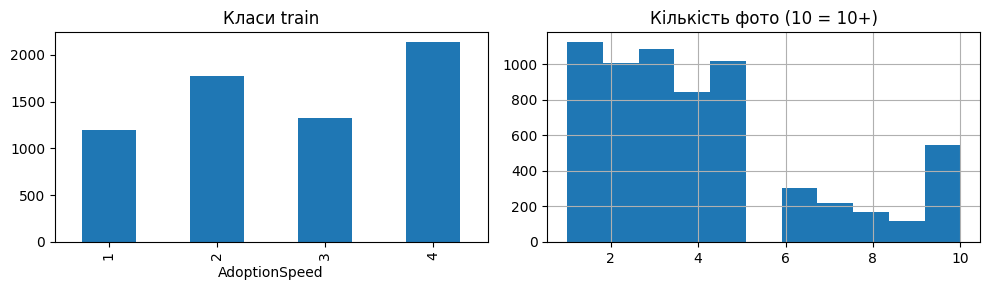

In [4]:
def image_records(ids,image_dir):
    positions={pet:i for i,pet in enumerate(ids)}
    groups=[[] for _ in ids]
    assert image_dir.is_dir(),image_dir
    for path in image_dir.rglob('*'):
        if not path.is_file() or path.suffix.lower() not in {'.jpg','.jpeg','.png','.webp','.bmp'}: continue
        pet=path.stem if path.stem in positions else None
        order=0
        if pet is None:
            for sep in ('-','_'):
                base,found,suffix=path.stem.rpartition(sep)
                if found and base in positions:
                    pet,order=base,int(suffix) if suffix.isdigit() else 10**6
                    break
        if pet is not None: groups[positions[pet]].append((order,path))
    records=[]
    for row,group in enumerate(groups):
        group.sort(key=lambda x:(x[0],x[1].name,str(x[1])))
        records.extend((row,slot,item[1]) for slot,item in enumerate(group[:3]))
    assert records,'Не знайдено фотографій.'
    return records,np.array([len(group) for group in groups])

records,photo_counts=image_records(ids,DATA_ROOT/'images')
eda=pd.DataFrame({'PetID':ids,'n_photos':photo_counts,
    'split':['train']*N+['test']*len(data.test),
    'text_length':pd.concat([data.train.Description,data.test.Description],ignore_index=True).fillna('').str.len()})
display(eda.groupby('split')[['n_photos','text_length']].describe())
display(data.train.AdoptionSpeed.value_counts().sort_index().rename('count'))
print('Порожні описи:',eda.groupby('split').text_length.apply(lambda x:int((x==0).sum())).to_dict())
print('Без фото:',eda.groupby('split').n_photos.apply(lambda x:int((x==0).sum())).to_dict())
fig,axes=plt.subplots(1,2,figsize=(10,3))
data.train.AdoptionSpeed.value_counts().sort_index().plot.bar(ax=axes[0],title='Класи train')
eda.loc[eda.split=='train','n_photos'].clip(upper=10).hist(ax=axes[1],bins=11)
axes[1].set_title('Кількість фото (10 = 10+)')
plt.tight_layout(); plt.show()
eda.to_csv(OUT/'eda.csv',index=False)

## 4. Заморожені ознаки: один витяг для всіх експериментів
ResNet18 дає середній вектор 512, DINOv2 — CLS-вектор 384. Для first/rest окремо
зберігаємо перше фото та середнє решти вибраних фото. Sentence embeddings — 768
ознак сирого опису, нормалізованих L2. Енкодери не навчаються на мітках; витяг
можна виконати для train і test разом. Кеш перевіряє ID, вміст файлів, версії та рецепт.

In [5]:
class PhotoDataset(Dataset):
    def __init__(self,records,transform): self.records,self.transform=records,transform
    def __len__(self): return len(self.records)
    def __getitem__(self,index):
        row,slot,path=self.records[index]
        try:
            with Image.open(path) as im: tensor=self.transform(im.convert('RGB'))
            ok=True
        except (OSError,ValueError):
            tensor=self.transform(Image.new('RGB',(224,224))); ok=False
        return tensor,row,slot,ok

def digest(value):
    return hashlib.sha256(json.dumps(value,ensure_ascii=False,sort_keys=True).encode()).hexdigest()

file_manifest=[(row,slot,str(path.relative_to(DATA_ROOT/'images')),
                hashlib.sha256(path.read_bytes()).hexdigest()) for row,slot,path in tqdm(records,desc='Відбитки фото')]

def cached(name,signature,compute):
    target=OUT/'feature_cache'/name
    choices=[target]+([Path(CACHE_INPUT)/name] if CACHE_INPUT else [])
    for path in choices:
        if not path.is_file(): continue
        with np.load(path,allow_pickle=False) as z:
            if str(z['signature'].item())!=signature or z['ids'].tolist()!=ids: continue
            arrays={key:z[key].copy() for key in z.files if key not in ['signature','ids']}
        if path!=target: shutil.copy2(path,target)
        print('Кеш:',path)
        return arrays
    arrays=compute()
    np.savez_compressed(target,ids=np.array(ids),signature=np.array(signature),**arrays)
    return arrays

def extract_photos(kind):
    signature=digest(dict(ids=ids,files=file_manifest,kind=kind,versions=VERSIONS,
        model=DINO_NAME if kind=='dino' else 'resnet18.IMAGENET1K_V1',revision=DINO_REV if kind=='dino' else '',recipe=1))
    def compute():
        seed_all(42)
        if kind=='resnet':
            weights=ResNet18_Weights.IMAGENET1K_V1
            transform=weights.transforms()
            model=resnet18(weights=weights); model.fc=nn.Identity()
            dim=512
        else:
            processor=AutoImageProcessor.from_pretrained(DINO_NAME,revision=DINO_REV,use_fast=False)
            transform=lambda im:processor(images=im,return_tensors='pt')['pixel_values'][0]
            model=AutoModel.from_pretrained(DINO_NAME,revision=DINO_REV)
            dim=384
        model.to(DEVICE).eval().requires_grad_(False)
        vectors=np.zeros((len(ids),3,dim),np.float32)
        valid=np.zeros((len(ids),3),bool)
        loader=DataLoader(PhotoDataset(records,transform),batch_size=32,shuffle=False,num_workers=0)
        with torch.inference_mode():
            for pixels,rows,slots,oks in tqdm(loader,desc=kind):
                output=model(pixels.to(DEVICE)) if kind=='resnet' else model(pixel_values=pixels.to(DEVICE)).last_hidden_state[:,0,:]
                output=output.cpu().numpy()
                for row,slot,ok,vector in zip(rows.tolist(),slots.tolist(),oks.tolist(),output):
                    if ok: vectors[row,slot]=vector; valid[row,slot]=True
        del model
        if DEVICE.type=='cuda': torch.cuda.empty_cache()
        return dict(vectors=vectors,valid=valid)
    result=cached(kind+'.npz',signature,compute)
    dim=512 if kind=='resnet' else 384
    assert result['vectors'].shape==(len(ids),3,dim) and np.isfinite(result['vectors']).all()
    assert result['valid'].shape==(len(ids),3)
    return result

def pooled(cache):
    vectors,valid=cache['vectors'],cache['valid']
    count=valid.sum(axis=1)
    mean=vectors.sum(axis=1)/np.maximum(count,1)[:,None]
    rest=vectors[:,1:].sum(axis=1)/np.maximum(valid[:,1:].sum(axis=1),1)[:,None]
    return np.column_stack([mean,count==0]).astype('float32'),np.column_stack([
        vectors[:,0],rest,~valid[:,0],~valid[:,1:].any(axis=1)]).astype('float32')

res_cache=extract_photos('resnet')
dino_cache=extract_photos('dino')
assert np.array_equal(res_cache['valid'],dino_cache['valid'])
resnet,_=pooled(res_cache)
dino,first_rest=pooled(dino_cache)
FEATURES={'resnet':resnet,'dino':dino,'first_rest':first_rest}
print('Без прочитаних фото train/test:',int((resnet[:N,-1]==1).sum()),int((resnet[N:,-1]==1).sum()))

if RUN_SENTENCE:
    texts=pd.concat([data.train.Description,data.test.Description],ignore_index=True).fillna('').astype(str).tolist()
    signature=digest(dict(ids=ids,texts=texts,model=TEXT_NAME,revision=TEXT_REV,max_length=256,normalize=True,versions=VERSIONS))
    def compute_text():
        encoder=SentenceTransformer(TEXT_NAME,revision=TEXT_REV,device=str(DEVICE))
        encoder.max_seq_length=256
        encoder.eval().requires_grad_(False)
        vectors=encoder.encode(texts,batch_size=32,show_progress_bar=True,convert_to_numpy=True,normalize_embeddings=True).astype('float32')
        del encoder
        if DEVICE.type=='cuda': torch.cuda.empty_cache()
        return dict(vectors=vectors)
    FEATURES['sentence']=cached('sentence.npz',signature,compute_text)['vectors']
    assert FEATURES['sentence'].shape==(len(ids),768) and np.isfinite(FEATURES['sentence']).all()

Відбитки фото:   0%|          | 0/21011 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


resnet:   0%|          | 0/657 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/261 [00:00<?, ?it/s]

## 5. Спільні моделі, перетворення й калібрування
Для MLP: Dropout → Linear(128) → ReLU → Dropout → Linear(4), AdamW,
дві епохи. CatBoost: RMSE, 800 дерев, depth 6, learning rate 0.03.
Текстовий baseline: TF-IDF + LogisticRegression із balanced class weights.
Фото-baseline у чистовику — та сама MLP без тексту, щоб порівняння модальностей
було контрольованим; це не точне відтворення історичної лінійної голови Exp2.

Зберігаємо argmax і calibrated оцінки. Для подання наперед фіксуємо calibrated
для всіх неконстантних моделей. QWK підбору порогів на всіх OOF не трактуємо
як незалежну оцінку: перевірочна метрика походить лише з A↔B.

In [6]:
class Head(nn.Module):

    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(nn.Dropout(CFG['dropout']), nn.Linear(dim, CFG['hidden']), nn.ReLU(), nn.Dropout(CFG['dropout']), nn.Linear(CFG['hidden'], 4))

    def forward(self, x):
        return self.net(x)

def fit_head(xtr, ytr, fold, training_seed):
    seed_all(training_seed)
    model = Head(xtr.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(xtr), torch.as_tensor(ytr, dtype=torch.long)), batch_size=CFG['batch'], shuffle=True, generator=torch.Generator().manual_seed(training_seed))
    losses = []
    for epoch in range(1, CFG['epochs'] + 1):
        model.train()
        total = 0.0
        for (x, y) in loader:
            (x, y) = (x.to(DEVICE), y.to(DEVICE))
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += loss.item() * len(y)
        losses.append(total / len(ytr))
        print(f'Fold {fold}, seed {training_seed}, фіксована епоха {epoch}: train loss {losses[-1]:.4f}')
    return (model, losses)

def predict_probs(model, features):
    model.eval()
    chunks = []
    with torch.inference_mode():
        for (x,) in DataLoader(TensorDataset(torch.from_numpy(features)), batch_size=256):
            chunks.append(model(x.to(DEVICE)).softmax(dim=1).cpu().numpy())
    return np.concatenate(chunks)

def qwk(y, pred):
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side='right') + 1

def fit_thresholds(score, y):

    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < CFG['minimum_gap']:
            return 2.0
        return -qwk(y, decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(objective, bounds=[tuple(CFG['bounds'])] * 3, seed=CFG['optimizer_seed'], maxiter=CFG['maxiter'], popsize=CFG['popsize'], tol=CFG['tol'], polish=False, workers=1, updating='immediate', x0=initial)
    learned = np.sort(result.x)
    if objective(learned) >= objective(initial):
        learned = initial
    return (learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev), calibration_qwk=qwk(y, decode(score, learned))))

def feature_matrices(tr,ev,names,save_dir=None):
    tfidf=TfidfVectorizer(ngram_range=(1,2),min_df=CFG['min_df'],max_features=CFG['max_features'])
    texts=pd.concat([data.train.text_clean,data.test.text_clean],ignore_index=True)
    sparse_tr=tfidf.fit_transform(texts.iloc[tr])
    sparse_ev=tfidf.transform(texts.iloc[ev])
    svd=TruncatedSVD(n_components=CFG['svd_dim'],random_state=42)
    text_tr=svd.fit_transform(sparse_tr); text_ev=svd.transform(sparse_ev)
    matrices={'text':(sparse_tr,sparse_ev)}
    scalers={}
    for name in names-{'text','majority'}:
        image_name={'resnet_sentence':'resnet','dino_sentence':'dino','photo':'resnet'}.get(name,name)
        parts=[FEATURES[image_name][tr]]; eval_parts=[FEATURES[image_name][ev]]
        if name not in ['photo','resnet_sentence']:
            parts.append(text_tr); eval_parts.append(text_ev)
        if name in ['resnet_sentence','dino_sentence']:
            parts.append(FEATURES['sentence'][tr]); eval_parts.append(FEATURES['sentence'][ev])
        scaler=StandardScaler()
        matrices[name]=(scaler.fit_transform(np.column_stack(parts)).astype('float32'),
                        scaler.transform(np.column_stack(eval_parts)).astype('float32'))
        scalers[name]=scaler
    if save_dir:
        joblib.dump(dict(tfidf=tfidf,svd=svd,scalers=scalers),save_dir/'preprocessing.joblib')
    return matrices

SPECS={
 'majority':('majority','majority',[42]),
 'text_lr':('lr','text',[42]),
 'photo_mlp':('mlp','photo',[42]),
 'resnet_mlp':('mlp','resnet',[42]),
 'resnet_cb':('cb','resnet',[42]),
 'dino_mlp':('mlp','dino',[42]),
 'dino_cb':('cb','dino',[42]),
 'first_rest':('mlp','first_rest',[42,123,2026]),
}
if RUN_SENTENCE:
    SPECS.update(resnet_sentence=('mlp','resnet_sentence',[42]),dino_sentence=('mlp','dino_sentence',[42]))

def fit_models(tr,ev,specs,save_dir=None):
    matrices=feature_matrices(tr,ev,{x[1] for x in specs.values()},save_dir)
    scores,raw,logs={},{},[]
    for name,(kind,feature,seeds) in specs.items():
        if kind=='majority':
            label=int(np.bincount(y[tr],minlength=5)[1:].argmax()+1)
            scores[name]=np.full(len(ev),label,dtype=float)
            raw[name]=np.full(len(ev),label)
            logs.append(dict(model=name,n_train=len(tr),majority_class=label))
            if save_dir: write_json(save_dir/'majority.json',{'class':label})
            continue
        xtr,xev=matrices[feature]
        if kind=='mlp':
            probs=[]
            for seed in seeds:
                model,losses=fit_head(xtr,y[tr]-1,name,seed)
                prob=predict_probs(model,xev); probs.append(prob)
                logs.append(dict(model=name,seed=seed,n_train=len(tr),epochs=CFG['epochs'],train_loss=losses[-1]))
                if save_dir: torch.save(dict(state_dict={k:v.cpu() for k,v in model.state_dict().items()},input_dim=xtr.shape[1],config=CFG),save_dir/f'{name}_{seed}.pt')
                del model
            if name=='first_rest':
                scores['first_single']=probs[0]@np.arange(1,5)
                raw['first_single']=probs[0].argmax(axis=1)+1
            prob=np.mean(probs,axis=0)
            scores[name]=prob@np.arange(1,5); raw[name]=prob.argmax(axis=1)+1
            if DEVICE.type=='cuda': torch.cuda.empty_cache()
        else:
            if kind=='lr':
                model=LogisticRegression(C=1.,class_weight='balanced',max_iter=1000,random_state=42)
                model.fit(xtr,y[tr])
                prob=model.predict_proba(xev)
                assert np.array_equal(model.classes_,[1,2,3,4])
                scores[name]=prob@model.classes_; raw[name]=model.predict(xev)
                if save_dir: joblib.dump(model,save_dir/f'{name}.joblib')
            else:
                model=CatBoostRegressor(iterations=800,depth=6,learning_rate=.03,l2_leaf_reg=10,
                    loss_function='RMSE',random_seed=42,task_type='CPU',thread_count=4,allow_writing_files=False,verbose=200)
                model.fit(xtr,y[tr])
                scores[name]=model.predict(xev); raw[name]=np.clip(np.rint(scores[name]),1,4).astype(int)
                if save_dir: model.save_model(str(save_dir/f'{name}.cbm'))
            logs.append(dict(model=name,n_train=len(tr)))
            del model
    if {'resnet_mlp','resnet_cb'}<=scores.keys():
        scores['resnet_blend']=.5*scores['resnet_mlp']+.5*scores['resnet_cb']
    if {'dino_mlp','resnet_blend'}<=scores.keys():
        scores['exp22_recipe']=.5*scores['dino_mlp']+.5*scores['resnet_blend']
        if 'first_rest' in scores:
            scores['blend22_27']=.5*scores['exp22_recipe']+.5*scores['first_rest']
    return scores,raw,logs

def evaluate_cv(fold_seed,specs,folder):
    frame=pd.DataFrame({'PetID':data.train.PetID,'AdoptionSpeed':y,'fold':0,'evaluation_half':''})
    threshold_rows,training=[],[]
    for fold,(tr,va) in enumerate(StratifiedKFold(CFG['folds'],shuffle=True,random_state=fold_seed).split(data.train,y),1):
        print('Fold',fold,'seed',fold_seed)
        scores,raw,logs=fit_models(tr,va,specs)
        training.extend(dict(fold=fold,**entry) for entry in logs)
        frame.loc[va,'fold']=fold
        aa,bb=train_test_split(np.arange(len(va)),test_size=.5,random_state=CFG['split_seed'],stratify=y[va])
        frame.loc[va[aa],'evaluation_half']='A'; frame.loc[va[bb],'evaluation_half']='B'
        for name,score in scores.items():
            assert np.isfinite(score).all()
            frame.loc[va,name+'_score']=score
            pred=np.zeros(len(va),int)
            if name=='majority': pred=raw[name]
            else:
                for cal,eva,direction in [(aa,bb,'A_to_B'),(bb,aa,'B_to_A')]:
                    cuts,status=fit_thresholds(score[cal],y[va[cal]])
                    pred[eva]=decode(score[eva],cuts)
                    threshold_rows.append(dict(fold=fold,model=name,direction=direction,t1=cuts[0],t2=cuts[1],t3=cuts[2],**status))
            frame.loc[va,name+'_prediction']=pred
            if name in raw: frame.loc[va,name+'_raw']=raw[name]
        # Checkpoint: completed folds remain available if the session stops.
        frame.to_csv(folder/'oof_partial.csv',index=False)
    rows=[]
    for name in scores:
        for fold in list(range(1,CFG['folds']+1))+['ALL']:
            mask=np.ones(N,bool) if fold=='ALL' else frame.fold==fold
            pred=frame.loc[mask,name+'_prediction'].to_numpy(int)
            value=qwk(y[mask],pred)
            assert np.isclose(value,cohen_kappa_score(y[mask],pred,weights='quadratic'))
            row=dict(model=name,fold=str(fold),qwk=value,accuracy=accuracy_score(y[mask],pred))
            if name in raw: row['raw_qwk']=qwk(y[mask],frame.loc[mask,name+'_raw'])
            rows.append(row)
        pd.DataFrame(confusion_matrix(y,frame[name+'_prediction'],labels=[1,2,3,4]),index=[1,2,3,4],columns=[1,2,3,4]).to_csv(folder/f'confusion_{name}.csv')
    metrics=pd.DataFrame(rows)
    frame.to_csv(folder/'oof.csv',index=False)
    metrics.to_csv(folder/'metrics.csv',index=False)
    pd.DataFrame(training).to_csv(folder/'training.csv',index=False)
    pd.DataFrame(threshold_rows).to_csv(folder/'thresholds.csv',index=False)
    write_json(folder/'protocol.json',dict(fold_seed=fold_seed,config=CFG,specs=specs,fingerprint=data.fingerprint))
    return frame,metrics

## 6. Основні експерименти: однакова CV для всіх
Порівняння відбувається в межах цього прогону. `resnet_mlp` відповідає напряму
Exp15/16, `resnet_cb` — Exp18, `resnet_blend` — Exp19, `dino_mlp` — Exp21,
`exp22_recipe` — Exp22, `dino_cb` — Exp24, `first_single` — Exp25,
`first_rest` — Exp27. `resnet_sentence` і `dino_sentence` перевіряють Exp20/26.
`blend22_27` — нова гіпотеза: фіксоване середнє двох кандидатів, без пошуку ваг.
First/rest у разі пошкодженого першого фото явно зберігає його відсутність.
Точний збіг з історичними числами не гарантований через середовище та нову організацію обчислень.

### Результати чистового прогону
Значення нижче — QWK об’єднаних перевірочних прогнозів після калібрування A↔B,
не середнє п’яти QWK і не якість підбору порогів на всіх OOF. «—» означає,
що модель не перевірялася на другому розбитті.

| Модель | QWK, seed 42 | QWK, seed 2027 |
|---|---:|---:|
| Лише текст | 0.333383 | — |
| Лише фото ResNet | 0.480673 | — |
| ResNet + SVD, MLP | 0.494639 | 0.496853 |
| ResNet + SVD, CatBoost | 0.491100 | 0.490454 |
| ResNet MLP + CatBoost | 0.506114 | 0.498692 |
| DINOv2 mean + SVD | 0.535835 | 0.529859 |
| DINOv2 + CatBoost | 0.524000 | — |
| DINOv2 first/rest, один seed | 0.541897 | 0.530240 |
| DINOv2 first/rest, три seed | 0.547641 | 0.536948 |
| ResNet + sentence embeddings | 0.489150 | — |
| DINOv2 + SVD + sentence embeddings | 0.526968 | — |
| Рецепт Exp22 | 0.545344 | 0.539254 |
| Середнє Exp22 + first/rest (три seed) | 0.549969 | 0.552670 |

Фото дає сильніший окремий сигнал, ніж текст (0.480673 проти 0.333383).
Додавання SVD-тексту до фото підвищує QWK до 0.494639. Для ResNet MLP
калібрування підвищує QWK з argmax 0.468256 до 0.494639.
Заміна ResNet на DINOv2 дає 0.535835; об’єднання з ResNet-компонентами — 0.545344.
Перевірені sentence embeddings не покращують відповідні базові моделі.
Три seed first/rest покращують один seed, але ця модель сама по собі
не має стабільної переваги над рецептом Exp22 на двох розбиттях.


Fold 1 seed 42
Fold photo_mlp, seed 42, фіксована епоха 1: train loss 1.2677
Fold photo_mlp, seed 42, фіксована епоха 2: train loss 1.1801
Fold resnet_mlp, seed 42, фіксована епоха 1: train loss 1.2601
Fold resnet_mlp, seed 42, фіксована епоха 2: train loss 1.1370
0:	learn: 1.1145882	total: 164ms	remaining: 2m 10s
200:	learn: 0.8937687	total: 15.8s	remaining: 47.2s
400:	learn: 0.7982648	total: 31.2s	remaining: 31.1s
600:	learn: 0.7047526	total: 46.8s	remaining: 15.5s
799:	learn: 0.6246569	total: 1m 2s	remaining: 0us
Fold dino_mlp, seed 42, фіксована епоха 1: train loss 1.2323
Fold dino_mlp, seed 42, фіксована епоха 2: train loss 1.1229
0:	learn: 1.1132407	total: 92.9ms	remaining: 1m 14s
200:	learn: 0.8682460	total: 12.6s	remaining: 37.4s
400:	learn: 0.7805903	total: 24.8s	remaining: 24.7s
600:	learn: 0.6977138	total: 37.2s	remaining: 12.3s
799:	learn: 0.6267419	total: 49.7s	remaining: 0us
Fold first_rest, seed 42, фіксована епоха 1: train loss 1.2337
Fold first_rest, seed 42, фіксована

,model,fold,qwk,accuracy,raw_qwk
83,blend22_27,ALL,0.549969,0.467268,NaN
53,first_rest,ALL,0.547641,0.469911,0.509819
77,exp22_recipe,ALL,0.545344,0.464313,NaN
47,first_single,ALL,0.541897,0.465557,0.496030
35,dino_mlp,ALL,0.535835,0.467268,0.506891
65,dino_sentence,ALL,0.526968,0.450785,0.497279
41,dino_cb,ALL,0.524000,0.438346,0.439624
71,resnet_blend,ALL,0.506114,0.439434,NaN
23,resnet_mlp,ALL,0.494639,0.442233,0.468256
29,resnet_cb,ALL,0.491100,0.429171,0.383119


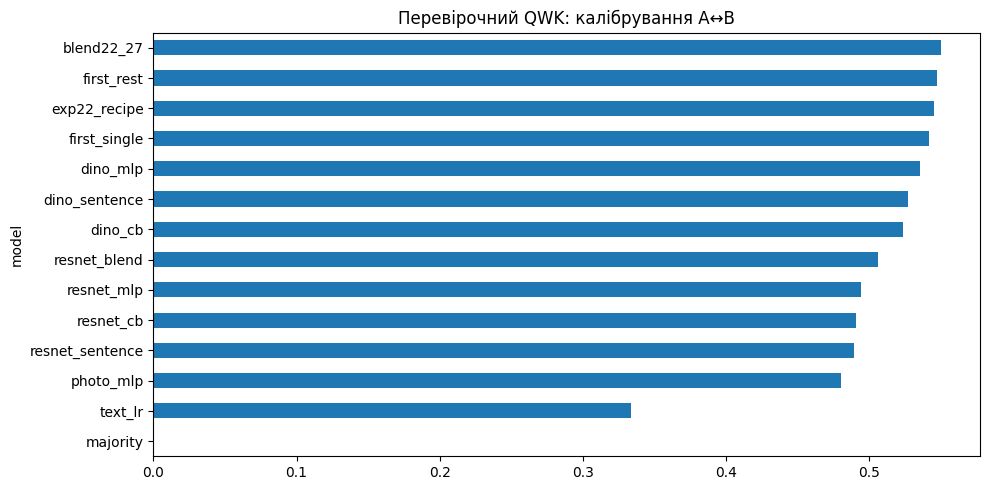

In [7]:
oof,metrics=evaluate_cv(42,SPECS,OUT/'cv42')
summary=metrics[metrics.fold=='ALL'].sort_values('qwk',ascending=False)
display(summary)
fig,ax=plt.subplots(figsize=(10,5))
summary.set_index('model').qwk.sort_values().plot.barh(ax=ax,title='Перевірочний QWK: калібрування A↔B')
plt.tight_layout(); plt.show()

## 7. Стійкість до нового розбиття
Заново навчаємо компоненти Exp22 і три seed first/rest на фолдах seed 2027.
Старі OOF не використовуються як прогнози нового розбиття. Додатково оцінюємо
заздалегідь зафіксований blend22_27. Зміна знаку різниці вказує на нестійкість
ранжування; окремий fold або стандартне відхилення не є доказом значущості.

**Результат.** Blend22_27 має QWK **0.549969** і **0.552670** на двох розбиттях.
Відносно Exp22 приріст становить **+0.004626** і **+0.013415**,
з покращенням відповідно на **3/5** і **4/5** фолдів.
Це найкращий перевірений локальний кандидат цього прогону й обґрунтування
окремого подання. Це не гарантія кращого public/private score і не доказ
статистичної значущості: ті самі профілі вже використовувалися у розробці.


In [8]:
if RUN_SENSITIVITY:
    sensitivity_specs={k:SPECS[k] for k in ['resnet_mlp','resnet_cb','dino_mlp','first_rest']}
    oof_new,metrics_new=evaluate_cv(2027,sensitivity_specs,OUT/'cv2027')
    compare=metrics_new[metrics_new.model.isin(['exp22_recipe','first_rest','blend22_27'])].pivot(index='fold',columns='model',values='qwk')
    compare['first_rest_minus_exp22']=compare.first_rest-compare.exp22_recipe
    display(compare)
    compare.to_csv(OUT/'cv2027'/'comparison.csv')

Fold 1 seed 2027
Fold resnet_mlp, seed 42, фіксована епоха 1: train loss 1.2537
Fold resnet_mlp, seed 42, фіксована епоха 2: train loss 1.1391
0:	learn: 1.1146469	total: 113ms	remaining: 1m 30s
200:	learn: 0.8930434	total: 15.9s	remaining: 47.5s
400:	learn: 0.8030993	total: 31.5s	remaining: 31.4s
600:	learn: 0.7130728	total: 47.2s	remaining: 15.6s
799:	learn: 0.6353329	total: 1m 2s	remaining: 0us
Fold dino_mlp, seed 42, фіксована епоха 1: train loss 1.2264
Fold dino_mlp, seed 42, фіксована епоха 2: train loss 1.1290
Fold first_rest, seed 42, фіксована епоха 1: train loss 1.2212
Fold first_rest, seed 42, фіксована епоха 2: train loss 1.1070
Fold first_rest, seed 123, фіксована епоха 1: train loss 1.2219
Fold first_rest, seed 123, фіксована епоха 2: train loss 1.1046
Fold first_rest, seed 2026, фіксована епоха 1: train loss 1.2290
Fold first_rest, seed 2026, фіксована епоха 2: train loss 1.1017
Fold 2 seed 2027
Fold resnet_mlp, seed 42, фіксована епоха 1: train loss 1.2611
Fold resnet_ml

model,blend22_27,exp22_recipe,first_rest,first_rest_minus_exp22
fold,,,,
1,0.539428,0.524940,0.512313,-0.012627
2,0.572553,0.558695,0.550124,-0.008571
3,0.550299,0.551629,0.529992,-0.021637
4,0.536991,0.502626,0.529654,0.027028
5,0.564451,0.557809,0.561609,0.003800
ALL,0.552670,0.539254,0.536948,-0.002307


## 8. Фінальне навчання на всіх розмічених даних
**Це окреме навчання з нуля, не усереднення моделей CV.** Для кожного кандидата
всі рядки train беруть участь у навчанні; зберігаємо preprocessing і ваги.
Кількість епох і всі параметри залишаються фіксованими. Для first/rest усереднюємо
три повністю навчені моделі з різними seed. Пороги для test підбираємо на всіх OOF
основного розбиття seed 42. Перенесення порогів з OOF на full-train є припущенням:
розподіл оцінок може змінитися. Тому full-train файл має власну назву й новий public score.


In [9]:
full_scores,full_raw,full_logs=fit_models(np.arange(N),np.arange(N,len(ids)),SPECS,OUT/'full_train')
pd.DataFrame(full_logs).to_csv(OUT/'full_train'/'training.csv',index=False)
assert all(row['n_train']==N for row in full_logs)
# Збереження до експорту: помилка формату CSV не вимагає повторного навчання.
pd.DataFrame({'PetID':data.test.PetID,**full_scores}).to_csv(OUT/'full_train'/'test_scores.csv',index=False)


Fold photo_mlp, seed 42, фіксована епоха 1: train loss 1.2652
Fold photo_mlp, seed 42, фіксована епоха 2: train loss 1.1878
Fold resnet_mlp, seed 42, фіксована епоха 1: train loss 1.2505
Fold resnet_mlp, seed 42, фіксована епоха 2: train loss 1.1377
0:	learn: 1.1146452	total: 114ms	remaining: 1m 31s
200:	learn: 0.9079760	total: 16.1s	remaining: 48s
400:	learn: 0.8293398	total: 31.8s	remaining: 31.6s
600:	learn: 0.7451458	total: 47.5s	remaining: 15.7s
799:	learn: 0.6717725	total: 1m 3s	remaining: 0us
Fold dino_mlp, seed 42, фіксована епоха 1: train loss 1.2194
Fold dino_mlp, seed 42, фіксована епоха 2: train loss 1.1254
0:	learn: 1.1128223	total: 98.9ms	remaining: 1m 19s
200:	learn: 0.8816325	total: 12.8s	remaining: 38.3s
400:	learn: 0.8056660	total: 25.4s	remaining: 25.2s
600:	learn: 0.7294129	total: 38s	remaining: 12.6s
799:	learn: 0.6641185	total: 50.7s	remaining: 0us
Fold first_rest, seed 42, фіксована епоха 1: train loss 1.2282
Fold first_rest, seed 42, фіксована епоха 2: train los

### Експорт без повторного навчання
Окрема комірка використовує готові `full_scores`. Якщо sample_submission точно
відповідає test, зберігаємо його порядок. Інакше записуємо всі унікальні PetID
з test.csv у його порядку та зберігаємо діагностику. За умовою порядок рядків
не має значення. Кількість і склад прогнозів завжди мають точно відповідати test.



In [10]:
def submission_order(test_ids, sample):
    expected=pd.Series(test_ids,dtype='string').reset_index(drop=True)
    assert expected.notna().all() and expected.str.strip().ne('').all() and expected.is_unique
    if sample is None:
        return expected, {'status':'sample_missing_use_test'}
    if 'PetID' not in sample.columns:
        return expected, {'status':'sample_no_PetID_use_test','sample_rows':len(sample)}
    candidate=sample.PetID.astype('string').str.strip()
    matches=(len(candidate)==len(expected) and candidate.notna().all()
             and candidate.is_unique and set(candidate)==set(expected))
    report=dict(status='sample_matches' if matches else 'sample_mismatch_use_test',
                test_rows=len(expected),sample_rows=len(candidate),
                sample_null_ids=int(candidate.isna().sum()),
                sample_duplicate_ids=int(candidate.duplicated().sum()),
                missing_test_ids=len(set(expected)-set(candidate.dropna())),
                extra_sample_ids=len(set(candidate.dropna())-set(expected)))
    return candidate.reset_index(drop=True) if matches else expected, report

sample_path=DATA_ROOT/'sample_submission.csv'
sample=pd.read_csv(sample_path,dtype={'PetID':str}) if sample_path.is_file() else None
submission_ids,sample_report=submission_order(data.test.PetID,sample)
print('Перевірка зразка:',sample_report)
write_json(OUT/'sample_submission_check.json',sample_report)
registry=[]; calibrations={}
test_scores=pd.DataFrame({'PetID':data.test.PetID})
for name,score in full_scores.items():
    assert np.asarray(score).shape==(len(data.test),) and np.isfinite(score).all(), name
    test_scores[name]=score
    if name=='majority': continue
    cuts,status=fit_thresholds(oof[name+'_score'].to_numpy(),y)
    calibrations[name]=dict(thresholds=cuts.tolist(),**status)
    pred=decode(score,cuts)
    output=pd.DataFrame({'PetID':data.test.PetID,'AdoptionSpeed':pred}).set_index('PetID').loc[submission_ids].reset_index()
    assert output.PetID.is_unique and output.AdoptionSpeed.isin([1,2,3,4]).all()
    path=OUT/'submissions'/f'submission_full_{name}.csv'
    output.to_csv(path,index=False)
    verified_qwk=float(summary.set_index('model').loc[name,'qwk'])
    registry.append(dict(candidate=name,file=path.name,n_train=N,cv_qwk=verified_qwk,
        public_score=None,sha256=hashlib.sha256(path.read_bytes()).hexdigest()))
    if name=='exp22_recipe': shutil.copy2(path,OUT/'submission.csv')
test_scores.to_csv(OUT/'full_train'/'test_scores.csv',index=False)
write_json(OUT/'full_train'/'calibration.json',calibrations)
pd.DataFrame(registry).to_csv(OUT/'submission_registry.csv',index=False)
display(pd.DataFrame(registry)[['candidate','file','n_train','cv_qwk','public_score']])
print('Кожен фінальний компонент навчено на',N,'рядках. Файли готові; public score ще невідомий.')

Перевірка зразка: {'status': 'sample_mismatch_use_test', 'test_rows': 1891, 'sample_rows': 4, 'sample_null_ids': 0, 'sample_duplicate_ids': 0, 'missing_test_ids': 1887, 'extra_sample_ids': 0}


,candidate,file,n_train,cv_qwk,public_score
0,text_lr,submission_full_text_lr.csv,6431,0.333383,None
1,photo_mlp,submission_full_photo_mlp.csv,6431,0.480673,None
2,resnet_mlp,submission_full_resnet_mlp.csv,6431,0.494639,None
3,resnet_cb,submission_full_resnet_cb.csv,6431,0.491100,None
4,dino_mlp,submission_full_dino_mlp.csv,6431,0.535835,None
5,dino_cb,submission_full_dino_cb.csv,6431,0.524000,None
6,first_single,submission_full_first_single.csv,6431,0.541897,None
7,first_rest,submission_full_first_rest.csv,6431,0.547641,None
8,resnet_sentence,submission_full_resnet_sentence.csv,6431,0.489150,None
9,dino_sentence,submission_full_dino_sentence.csv,6431,0.526968,None


Кожен фінальний компонент навчено на 6431 рядках. Файли готові; public score ще невідомий.


## 9. Історія дослідження й межі висновків
Ця таблиця з попередніх експериментів, це не результати
комірок вище. Holdout, CV і public мають різні вибірки й не порівнюються як одна метрика.

| Напрям | Історичний результат | Висновок |
|---|---:|---|
| Текст TF-IDF / фото ResNet | holdout 0.273 / 0.425 | Обидві модальності несуть сигнал |
| ResNet + BiLSTM / frozen DistilBERT | holdout 0.423 / 0.163 | У перевірених конфігураціях не покращили результат |
| ResNet + SVD128 (Exp5) | holdout 0.4639; public 0.6676 | Сильний початковий мультимодальний варіант |
| SVD512 / до 8 фото / кількість фото | holdout 0.473 / 0.471 / 0.446 | Немає підтвердженого стабільного приросту |
| Fine-tuning ResNet | holdout 0.402; теплий старт ≈0.463 | Не перевершив заморожені ознаки |
| Текстові зміни / ordinal loss | holdout до 0.478 | Невеликі зміни; інший протокол, не основний CV |
| Exp15 → Exp16: калібрування | CV 0.468256 → 0.494639 | Пороги корисні; перевіряємо поза калібрувальною половиною |
| Ridge / CatBoost ResNet / ансамбль | CV 0.468410 / 0.491100 / 0.506114 | Ансамбль доповнює MLP |
| Sentence embeddings замість SVD | CV 0.489150 | Не покращили ResNet MLP |
| DINOv2 mean / фінальний ансамбль | CV 0.535835 / 0.545344 | Основне покращення |
| Exp23: CV-ансамбль рецепта Exp22 | public **0.7550** | Повідомлено користувачем; не full-train результат |
| DINO CatBoost / first-rest / додані sentence | CV 0.524000 / 0.542031 / 0.526968 | First/rest перспективний, sentence не допомогли |
| First/rest, три seed | CV 0.547177 | Невелика перевага над Exp22 на першому розбитті |
| Exp28, нові фолди: Exp22 / Exp27 | CV 0.539254 / 0.535200 | Перевага Exp27 не підтвердилася |



## 10. Підсумки та фінальні артефакти

1. Заморожені фотоознаки несуть основний сигнал, а TF-IDF/SVD доповнює їх.
2. Калібрування порогів під цільову QWK корисне, якщо оцінювати його на інших
   прикладах, ніж ті, де підібрані пороги.
3. DINOv2 і поєднання різних моделей дали головні покращення. Sentence embeddings
   у перевірених конфігураціях не перевершили SVD-текст.
4. Фіксований blend Exp22 і first/rest із трьома seed має найвищий QWK
   на обох розбиттях: 0.549969 / 0.552670. Його варто подати окремо.
5. Усі фінальні компоненти заново навчено на **6431** розміченому профілі;
   для кожного кандидата створено **1891** тестовий прогноз. Пороги взято з OOF.


Обмеження: повторне використання навчальних даних під час розробки,
відсутність окремого недоторканого фінального набору, можливий зсув між train/test
і перенесення OOF-порогів на моделі, навчені на всьому train.



In [11]:
write_json(OUT/'run_manifest.json',dict(config=CFG,versions=VERSIONS,
    fingerprint=data.fingerprint,run_sentence=RUN_SENTENCE,run_sensitivity=RUN_SENSITIVITY,
    dino=dict(name=DINO_NAME,revision=DINO_REV),text=dict(name=TEXT_NAME,revision=TEXT_REV),
    final_training='all labeled train.csv rows',submission_recipe='exp22_recipe'))
import zipfile
archive=OUT.parent/'adoption_clean_results.zip'
with zipfile.ZipFile(archive,'w',compression=zipfile.ZIP_DEFLATED) as z:
    for path in sorted(OUT.rglob('*')):
        if path.is_file() and path.suffix in {'.csv','.json'} and 'feature_cache' not in path.parts:
            z.write(path,path.relative_to(OUT))
display(FileLink(str(archive)))
display(FileLink(str(OUT/'submission.csv')))

/kaggle/working/adoption_clean_results.zip

/kaggle/working/adoption_clean/submission.csv